### Compare cellchat results from separate zones

In [1]:
#remotes::install_github("jinworks/CellChat@88c2e13")

suppressPackageStartupMessages({
    library(CellChat)
    library(zellkonverter)
    library(SingleCellExperiment())
    library(ComplexHeatmap)
})



In [2]:
library(tidyr)
library(tibble)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand


The following object is masked from ‘package:igraph’:

    crossing



Attaching package: ‘tibble’


The following object is masked from ‘package:igraph’:

    as_data_frame




In [3]:
dist_out_dir <- "/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance"
dist_out_dir_cellchat <- "/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance/cellchat_zones_separate"
plot_out_dir <- file.path(dist_out_dir_cellchat, "plots")

## Load cellchat results

In [4]:
cellchat_tls =  readRDS(file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_contact_10_popsize_FALSETLS.rds"))

cellchat_bronchi =  readRDS(file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_contact_10_popsize_FALSEbronchi.rds"))

cellchat_vessels =  readRDS(file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_contact_10_popsize_FALSEvessels.rds"))

cellchat_adv =  readRDS(file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_contact_10_popsize_FALSEadventitia.rds"))

cellchat_paren =  readRDS(file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_contact_10_popsize_FALSEparenchyma.rds"))



## Plotting palettes


In [5]:
celltype_palette_mapped <- c('AT1'= '#ffff00',
 'AT2'= '#1ce6ff',
 'Club'= '#ff34ff',
 'Ciliated'= '#ff4a46',
 'SMC'= '#008941',
 'Col13a1+ fibroblast'= '#006fa6',
 'Col14a1+ fibroblast'= '#a30059',
 'Myofibroblast'= '#ffdbe5',
 'Pericyte 1'= '#7a4900',
 'Pericyte 2'= '#0000a6',
 'Mesothelial'= '#63ffac',
 'Cap'= '#b79762',
 'Cap-a'= '#004d43',
 'Art'= '#8fb0ff',
 'Vein'= '#997d87',
 'Lymph'= '#5a0007',
 'Mono'= '#809693',
 'Int Mf'= '#6a3a4c',
 'Alv Mf'= '#1b4400',
 'Neut'= '#4fc601',
 'cDC1'= '#3b5dff',
 'Ccr7- cDC2'= '#4a3b53',
 'Ccr7+ cDC2'= '#ff2f80',
 'B cell'= '#61615a',
 'Plasmablast'= '#ba0900',
 'NK cell'= '#6b7900',
 'gd T cell'= '#00c2a0',
 'ILC2'= '#ffaa92',
 'CD8 naive'= '#ff90c9',
 'CD8 act'= '#b903aa',
 'CD4 naive'= '#d16100',
 'Th0'='#8B0000',
 'CD4 trans'= '#6495ED',
 'Th1'= '#7b4f4b',
 'Th17'= '#DAA520',
 'Th2'= '#300018',
 'Treg'= '#556B2F'                           
)

## Run netAnalysis_computeCentrality

In [6]:
cellchat_tls <- netAnalysis_computeCentrality(cellchat_tls, slot.name = "netP")
cellchat_bronchi <- netAnalysis_computeCentrality(cellchat_bronchi, slot.name = "netP")
cellchat_vessels <- netAnalysis_computeCentrality(cellchat_vessels, slot.name = "netP")
cellchat_adv <- netAnalysis_computeCentrality(cellchat_adv, slot.name = "netP")
cellchat_paren <- netAnalysis_computeCentrality(cellchat_paren, slot.name = "netP")

## Plotting

In [7]:
# create named list of cellchat objects
chat_list <- list(
    "TLS" = cellchat_tls,
    "bronchi" = cellchat_bronchi,
    "vessels" = cellchat_vessels,
    "adventitia" = cellchat_adv,
    "parenchyma" = cellchat_paren
)

In [8]:
#' Update CellChat labels and order
#' @param chat_list A named list of CellChat objects
#' @param mapping_path Path to the CSV containing 'label_fine'
update_chat_metadata <- function(chat_list, mapping_path) {
  # Load the ordering dataframe
  label_df <- read.csv(mapping_path)
  
  updated_list <- lapply(names(chat_list), function(obj_name) {
    message(paste("Processing metadata for:", obj_name))
    obj <- chat_list[[obj_name]]
    
    # Identify labels present in the current object
    cellchat_labels <- unique(obj@idents)
    
    # Filter and reverse the ordered labels from the CSV
    ordered_labels <- label_df$label_fine[label_df$label_fine %in% cellchat_labels]
    cell_order <- rev(ordered_labels)
    
    # Update factors and cluster labels
    obj@meta$labels <- factor(obj@idents, levels = cell_order)
    obj <- updateClusterLabels(obj, new.order = cell_order)
    
    return(obj)
  })
  
  names(updated_list) <- names(chat_list)
  return(updated_list)
}

In [24]:
#' Plot CellChat interactions
#' @param chat_list Named list of updated CellChat objects
#' @param pathway String name of the signaling pathway
#' @param interaction_df The interaction dataframe/row to plot
#' @param out_dir Directory to save results
#' @param palette A named vector of colors
#' @param show_inline Boolean; if TRUE, prints plots to the console/notebook
plot_pathway_results <- function(chat_list, pathway, interaction_df, out_dir, palette, show_inline = TRUE) {
  
  for (obj_name in names(chat_list)) {
    obj <- chat_list[[obj_name]]
    
    # 1. Defensive Check: Is the pathway present in this object?
    if (!(pathway %in% obj@netP$pathways)) {
      message(paste("Skipping", obj_name, ": Pathway", pathway, "not significant."))
      next
    }
    
    # 2. Check for significant interactions
    df.net <- tryCatch({
      subsetCommunication(obj, pairLR.use = interaction_df)
    }, error = function(e) return(NULL))
    
    if (is.null(df.net) || nrow(df.net) == 0) {
      message(paste("Skipping", obj_name, ": No significant interactions."))
      next
    }
    
    # 3. Setup colors
    current_order <- levels(obj@idents)
    obj_palette <- palette[current_order]
    
    # --- BUBBLE PLOT ---
    p1 <- netVisual_bubble(
      obj,
      pairLR.use = interaction_df,
      remove.isolate = TRUE, 
      title.name = paste0(obj_name, " - ", interaction_df$interaction_name)
    )
    
    # Save
    ggsave(
      filename = file.path(out_dir, paste0(interaction_df$interaction_name, "_", obj_name, "_bubble_plot.pdf")), 
      plot = p1, width = 8, height = 6
    )
    
    # Inline print for ggplot
    if (show_inline) {
      print(p1)
    }
    
    # --- CIRCLE PLOT ---
    # Save to PDF
    plot_path_circle <- file.path(out_dir, paste0(interaction_df$interaction_name, "_", obj_name, "_circle_plot.pdf"))
    pdf(plot_path_circle)
    netVisual_individual(
      obj,
      signaling = pathway,          
      pairLR.use = interaction_df$interaction_name, 
      layout = "circle",
      color.use = obj_palette
    )
    dev.off()
    
    # Inline print for Base R (simply call the function again)
    if (show_inline) {
      netVisual_individual(
        obj,
        signaling = pathway,          
        pairLR.use = interaction_df$interaction_name, 
        layout = "circle",
        color.use = obj_palette
      )
    }
    
    message(paste("Successfully processed:", obj_name))
  }
}

In [10]:
# Define paths
mapping_file <- "/home/workspace/spatial_tls_manuscript/inputs/20250519_mouse_lung_label_mapping_ordered.csv"

# Step 1: Update the objects
chat_list <- update_chat_metadata(chat_list, mapping_file)



Processing metadata for: TLS



Only reorder cell groups but do not rename cell groups!

Reorder cell groups! 



The cell group order before reordering is  AT1 AT2 Club Ciliated SMC Col13a1+ fibroblast Col14a1+ fibroblast Myofibroblast Pericyte 1 Pericyte 2 Mesothelial Cap Cap-a Art Vein Lymph Mono Int Mf Alv Mf Neut cDC1 Ccr7- cDC2 Ccr7+ cDC2 B cell Plasmablast NK cell gd T cell ILC2 CD8 naive CD8 act CD4 naive Th0 CD4 trans Th1 Th17 Th2 Treg 
The cell group order after reordering is  Treg Th2 Th17 Th1 CD4 trans Th0 CD4 naive CD8 act CD8 naive ILC2 gd T cell NK cell Plasmablast B cell Ccr7+ cDC2 Ccr7- cDC2 cDC1 Neut Alv Mf Int Mf Mono Lymph Vein Art Cap-a Cap Mesothelial Pericyte 2 Pericyte 1 Myofibroblast Col14a1+ fibroblast Col13a1+ fibroblast SMC Ciliated Club AT2 AT1 


We now re-run computeCommunProbPathway`,`aggregateNet`, and `netAnalysis_computeCentrality`...

Processing metadata for: bronchi



...

We now re-run computeCommunProbPathway`,`aggregateNet`, and `netAnalysis_computeCentrality`...

Processing metadata for: parenchyma



Only reorder cell groups but do not rename cell groups!

Reorder cell groups! 



The cell group order before reordering is  AT1 AT2 Club Ciliated SMC Col13a1+ fibroblast Col14a1+ fibroblast Myofibroblast Pericyte 1 Pericyte 2 Mesothelial Cap Cap-a Art Vein Lymph Mono Int Mf Alv Mf Neut cDC1 Ccr7- cDC2 Ccr7+ cDC2 B cell Plasmablast NK cell gd T cell ILC2 CD8 naive CD8 act CD4 naive Th0 CD4 trans Th1 Th17 Th2 Treg 
The cell group order after reordering is  Treg Th2 Th17 Th1 CD4 trans Th0 CD4 naive CD8 act CD8 naive ILC2 gd T cell NK cell Plasmablast B cell Ccr7+ cDC2 Ccr7- cDC2 cDC1 Neut Alv Mf Int Mf Mono Lymph Vein Art Cap-a Cap Mesothelial Pericyte 2 Pericyte 1 Myofibroblast Col14a1+ fibroblast Col13a1+ fibroblast SMC Ciliated Club AT2 AT1 


We now re-run computeCommunProbPathway`,`aggregateNet`, and `netAnalysis_computeCentrality`...



### IL21

Comparing communications on a single object 


Successfully processed: TLS

Skipping bronchi : No significant interactions.

Skipping vessels : No significant interactions.

Comparing communications on a single object 




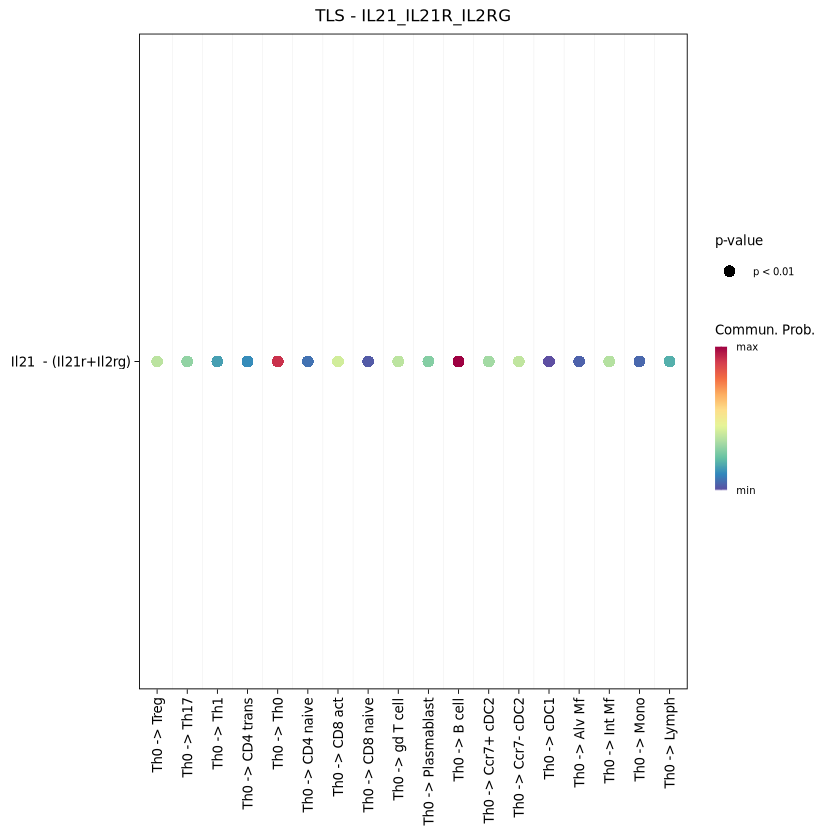

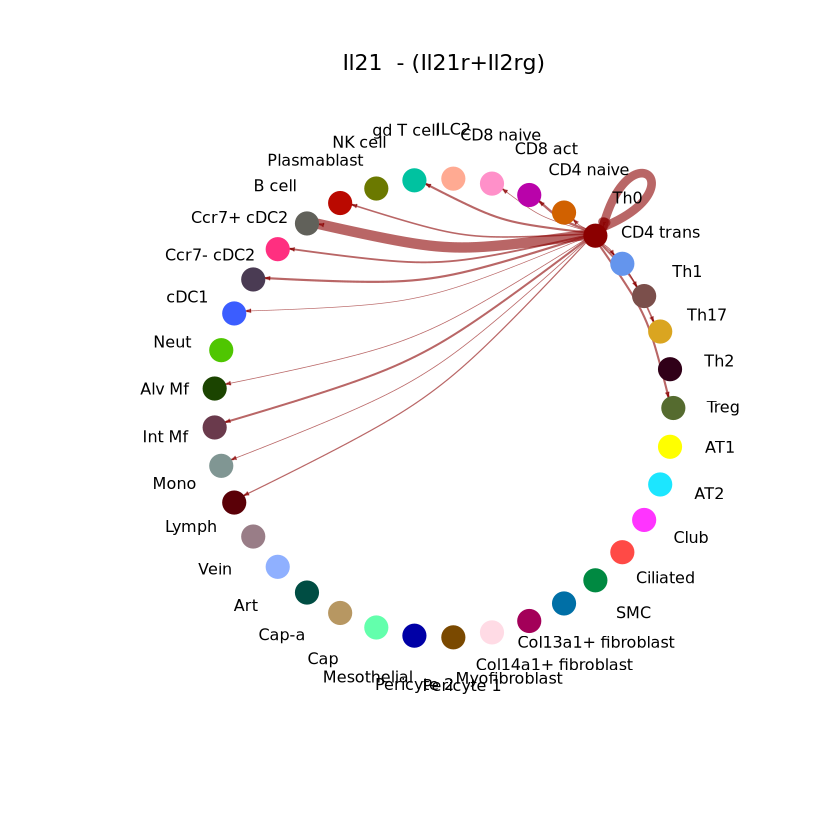

Successfully processed: adventitia

Comparing communications on a single object 




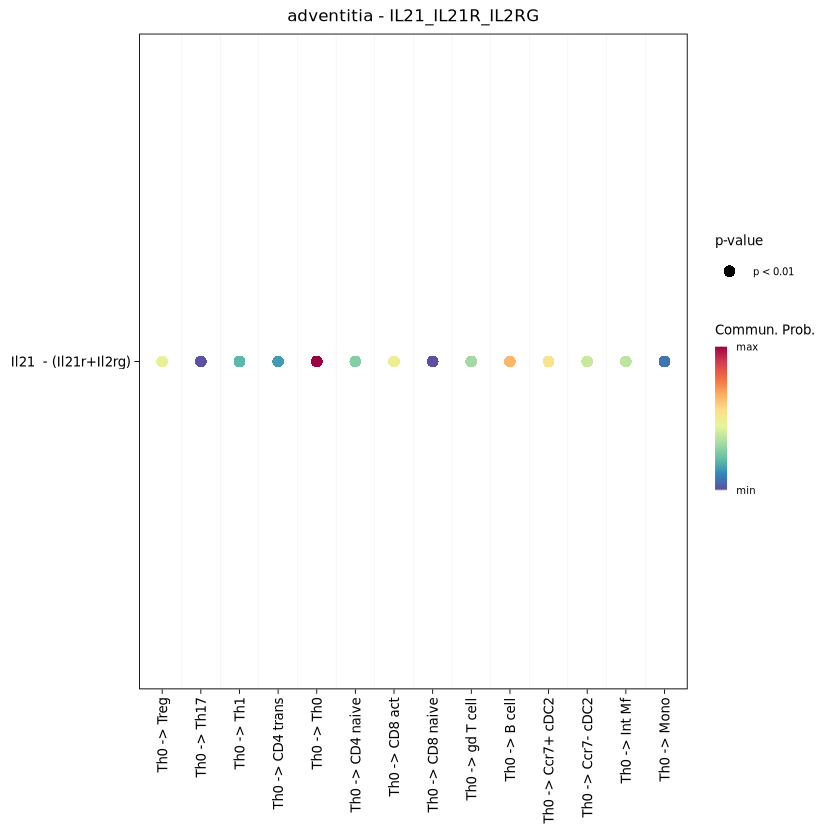

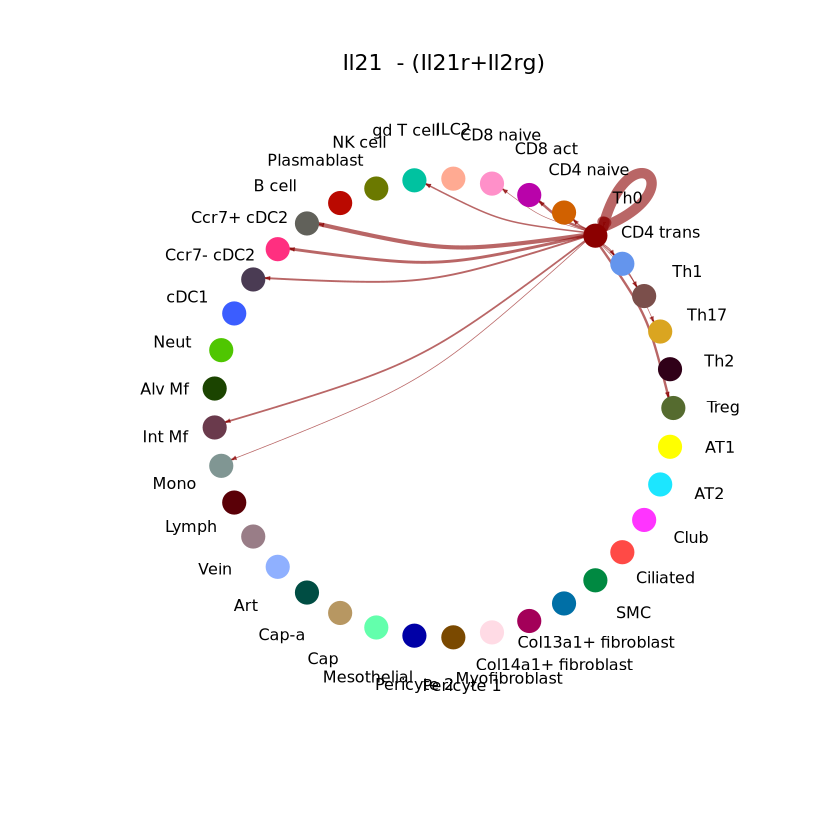

Successfully processed: parenchyma



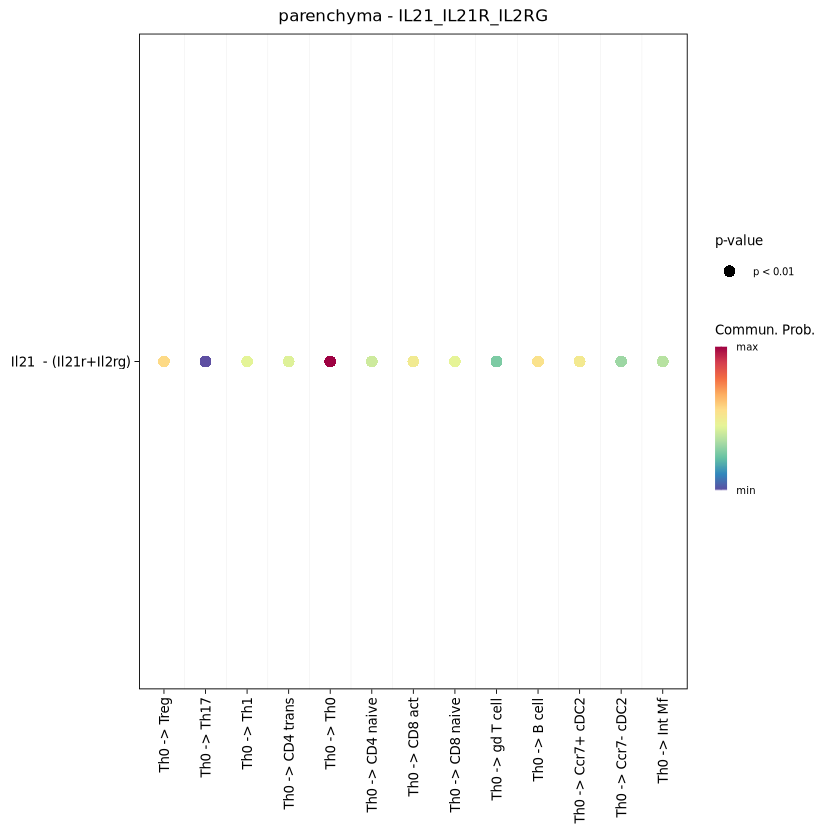

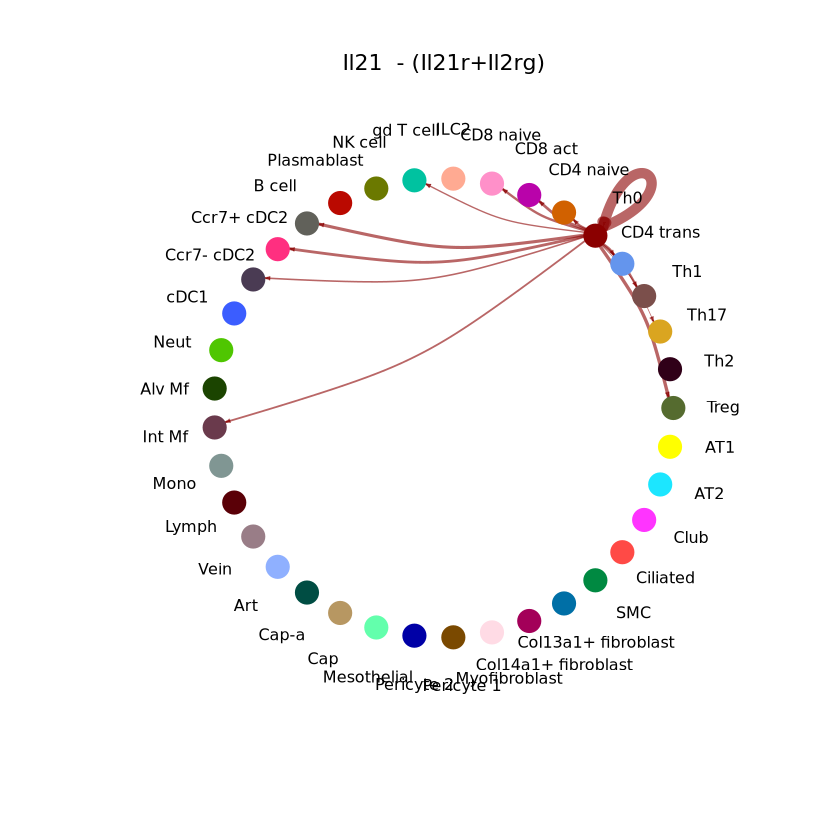

In [25]:
# Make plots
pairLR.use <- extractEnrichedLR(cellchat_tls, signaling = c("IL2"))
single_interaction <- pairLR.use[pairLR.use$interaction_name == "IL21_IL21R_IL2RG", , drop = FALSE]

plot_pathway_results(
    chat_list = chat_list, 
    pathway = 'IL2',
    interaction = single_interaction, 
    out_dir = plot_out_dir, 
    palette = celltype_palette_mapped
)

### PD1

In [23]:
# PD1 setup
pairLR.use <- extractEnrichedLR(cellchat_tls, signaling = c("PD-L1"))
single_interaction <- pairLR.use[pairLR.use$interaction_name == "CD274_PDCD1", , drop = FALSE]


pairLR.use <- extractEnrichedLR(cellchat_tls, signaling = c("PDL2"))
single_interaction <- pairLR.use[pairLR.use$interaction_name == "PDCD1LG2_PDCD1", , drop = FALSE]


Comparing communications on a single object 


Successfully processed: TLS

Skipping bronchi : Pathway PDL2 not significant.

Skipping vessels : Pathway PDL2 not significant.

Comparing communications on a single object 




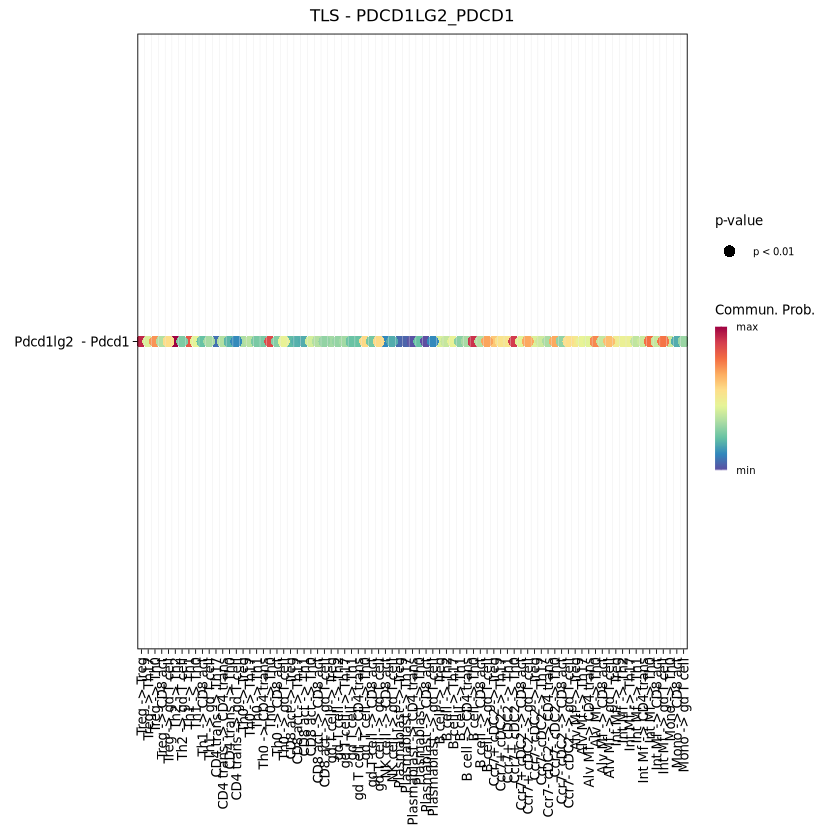

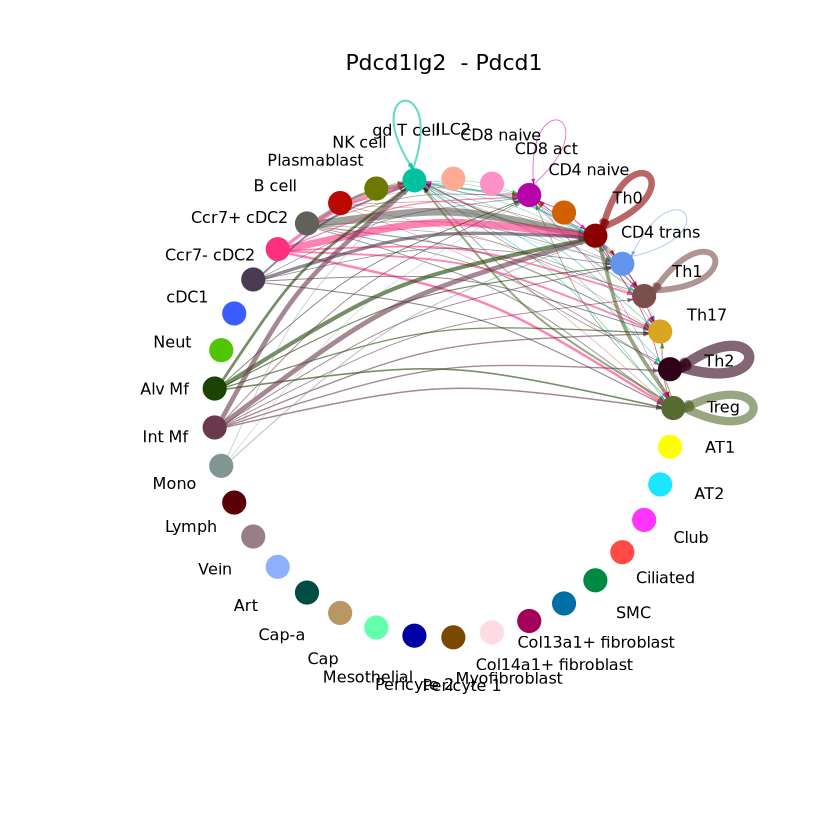

Successfully processed: adventitia

Comparing communications on a single object 




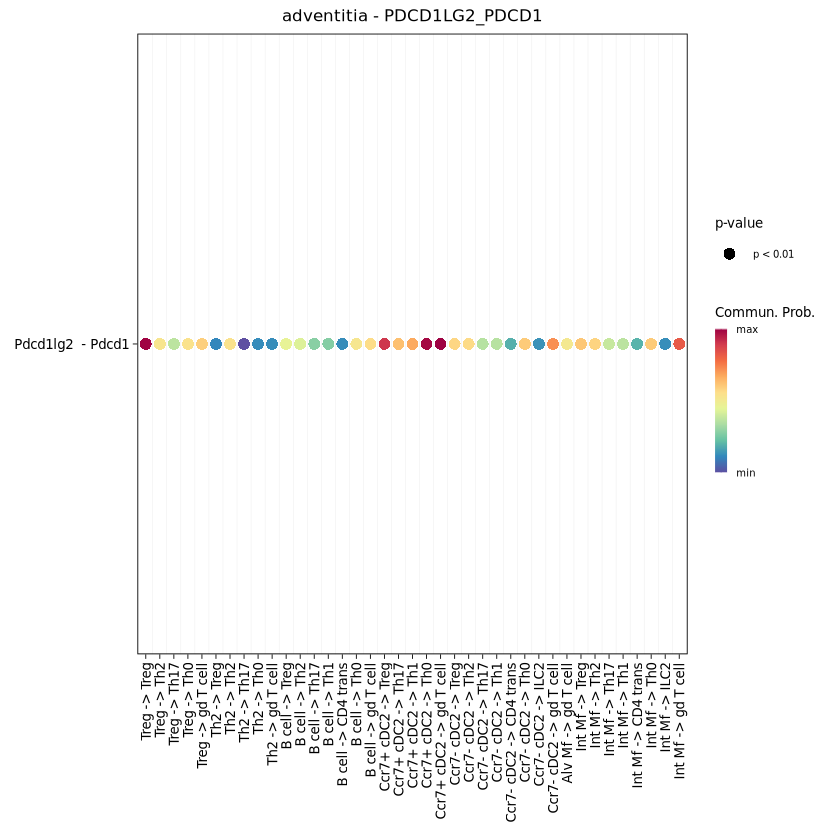

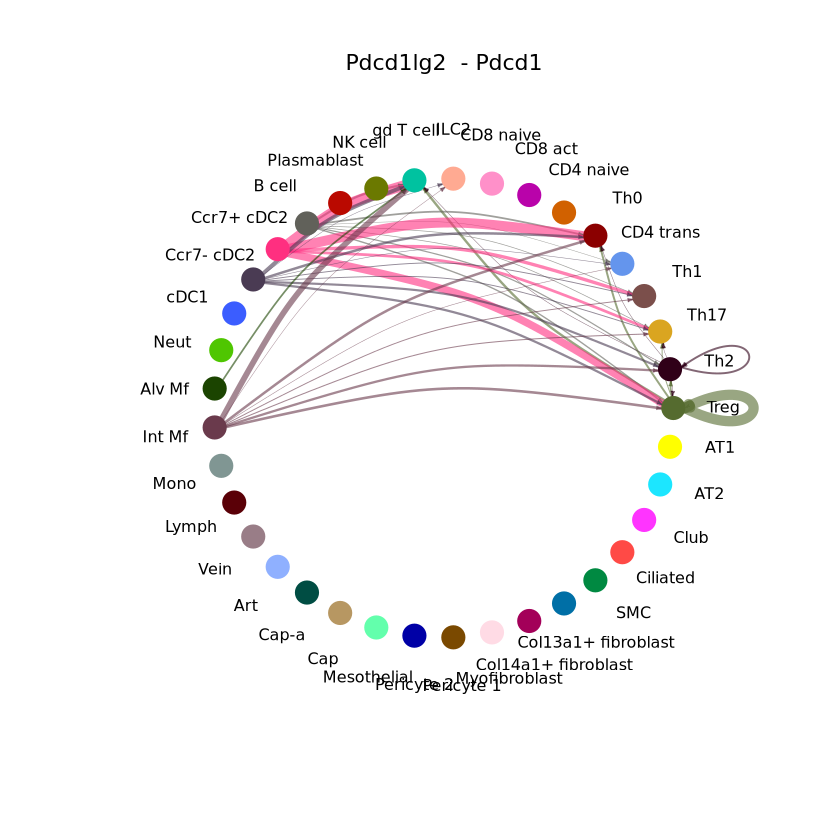

Successfully processed: parenchyma



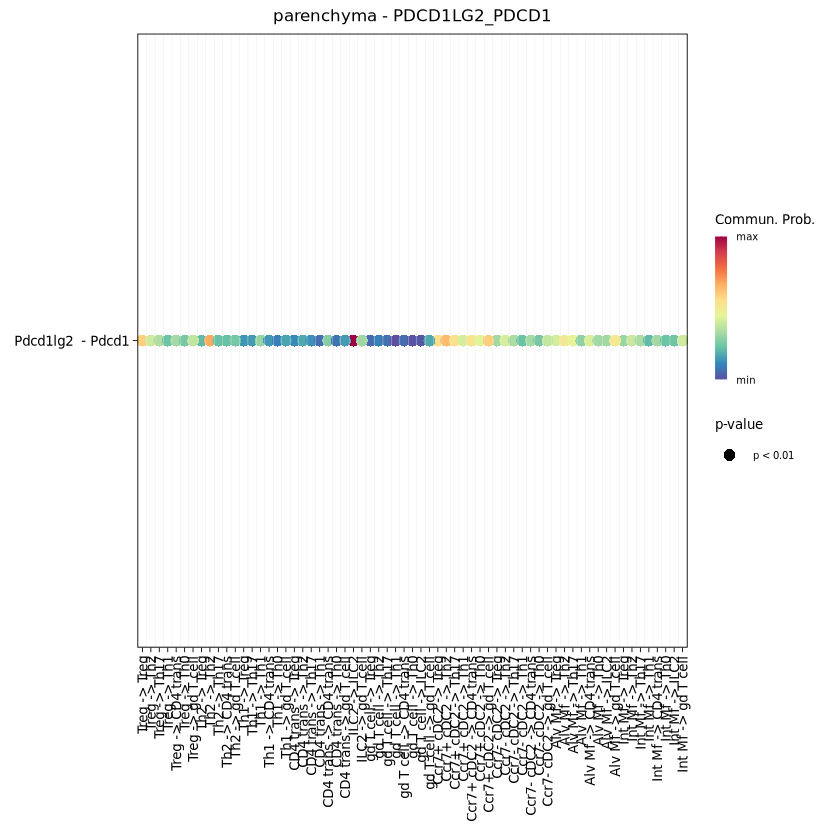

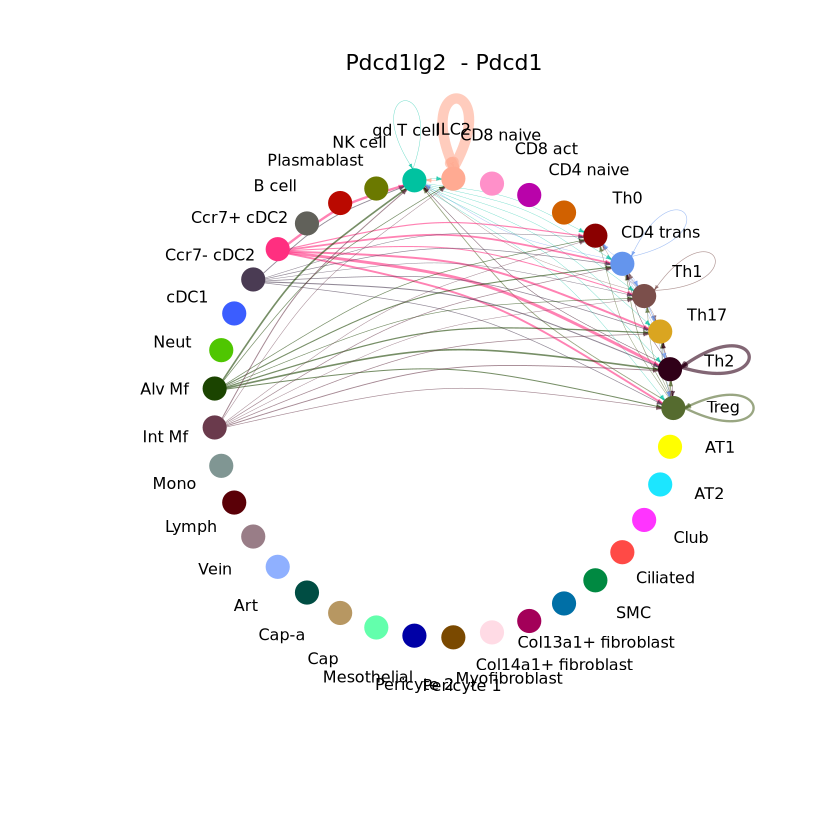

In [27]:
# PDL2
pairLR.use <- extractEnrichedLR(cellchat_tls, signaling = c("PDL2"))
single_interaction <- pairLR.use[pairLR.use$interaction_name == "PDCD1LG2_PDCD1", , drop = FALSE]

plot_pathway_results(
    chat_list = chat_list, 
    pathway = 'PDL2',
    interaction = single_interaction, 
    out_dir = plot_out_dir, 
    palette = celltype_palette_mapped
)

Comparing communications on a single object 


Successfully processed: TLS

Skipping bronchi : Pathway PD-L1 not significant.

Comparing communications on a single object 




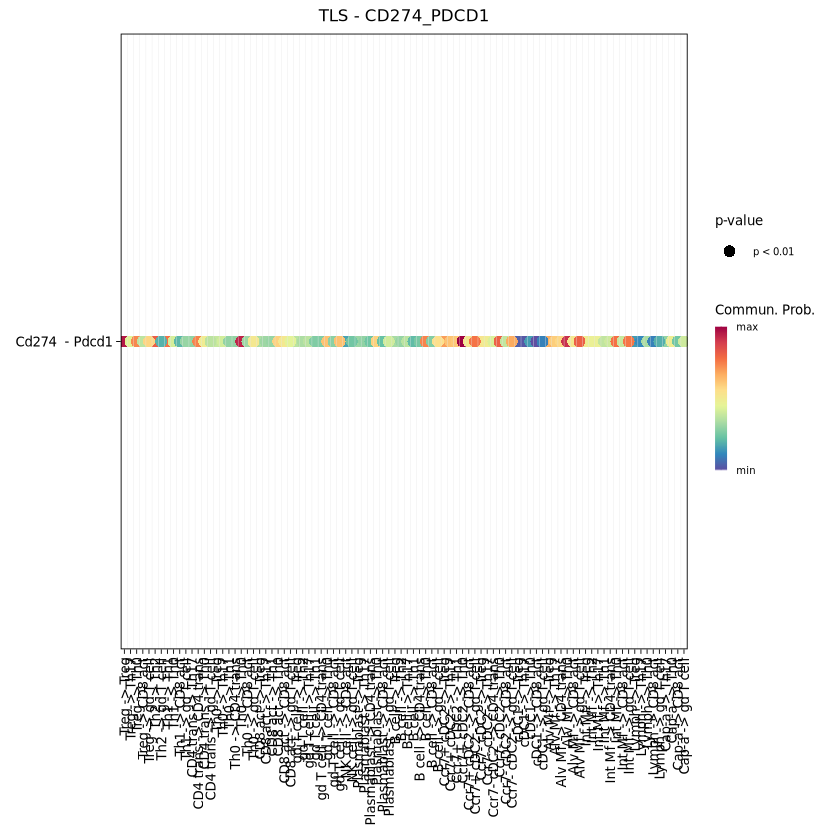

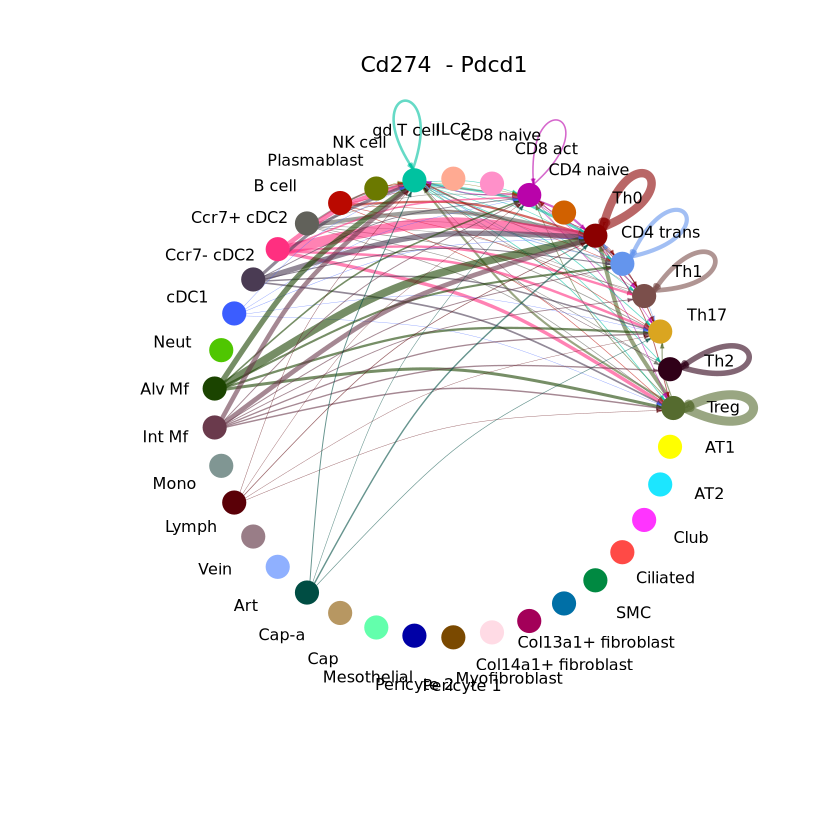

Successfully processed: vessels

Comparing communications on a single object 




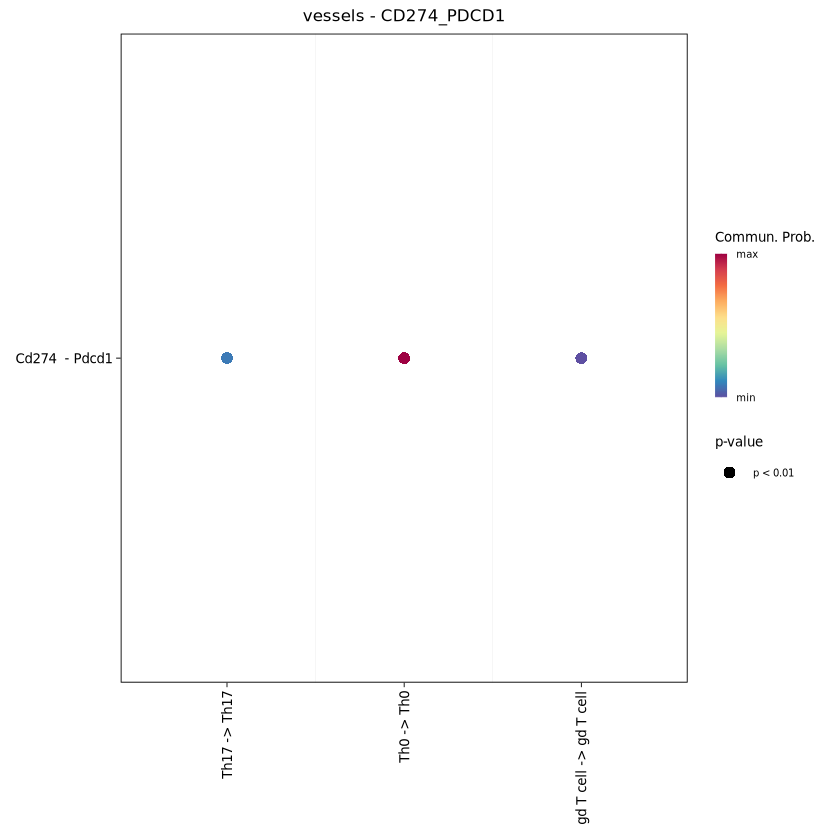

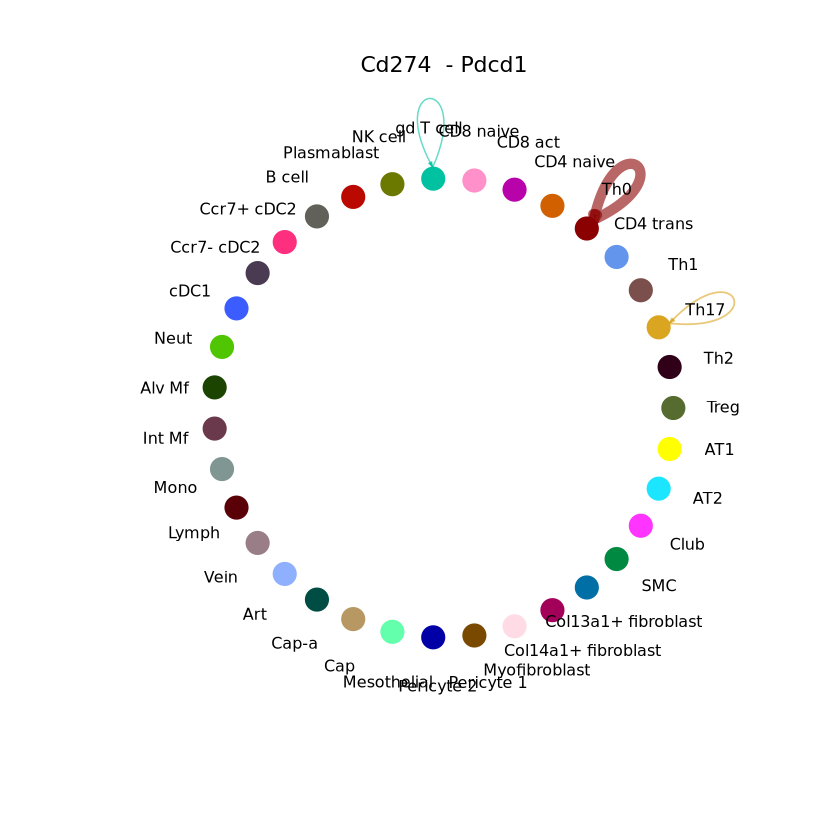

Successfully processed: adventitia

Comparing communications on a single object 




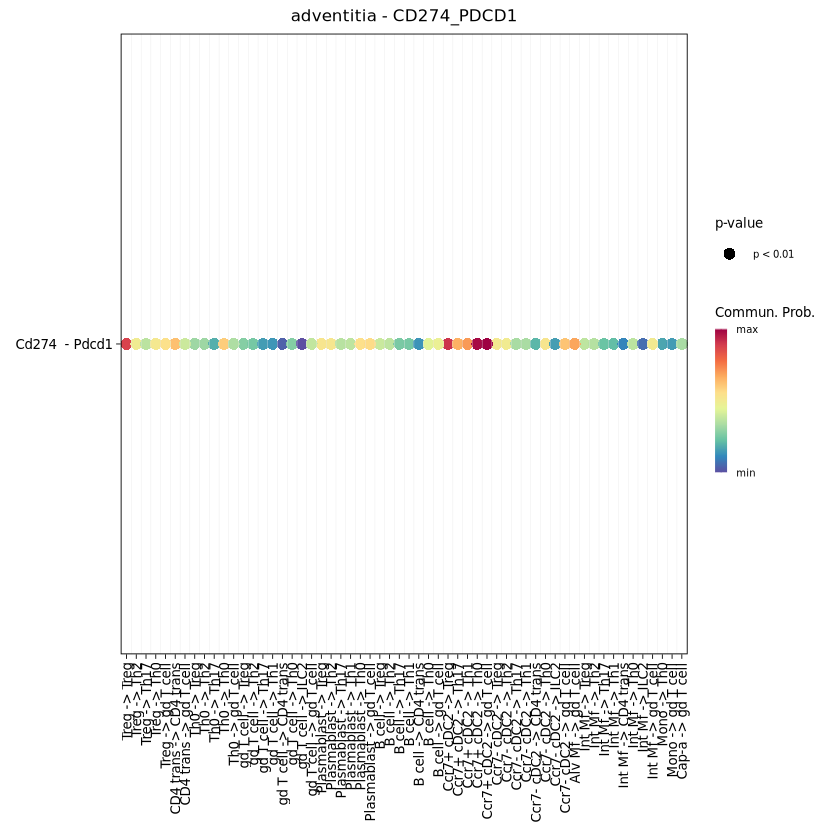

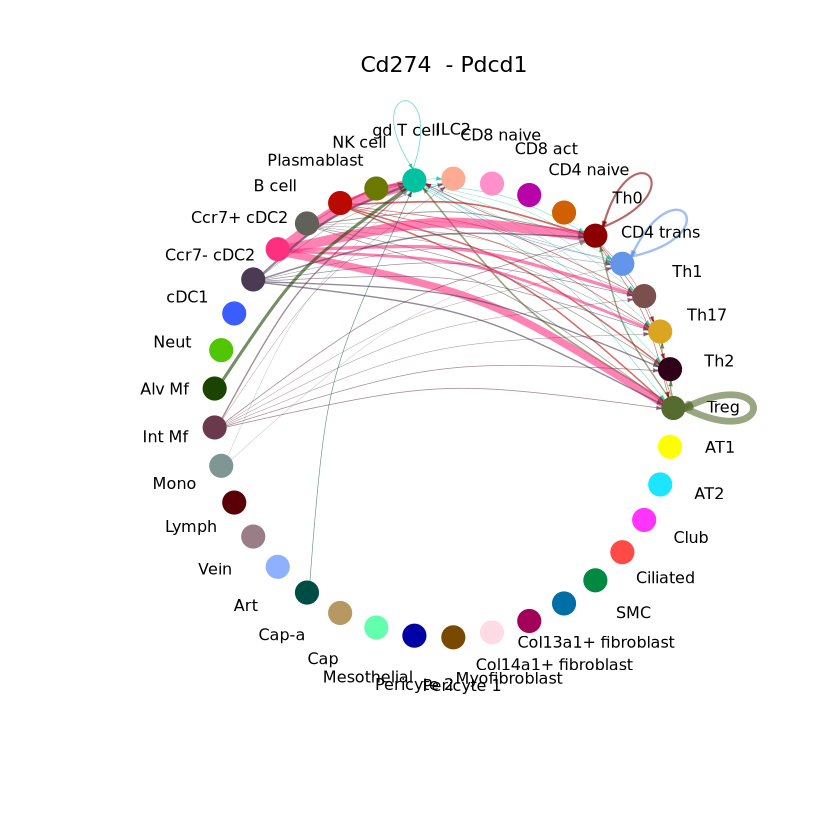

Successfully processed: parenchyma



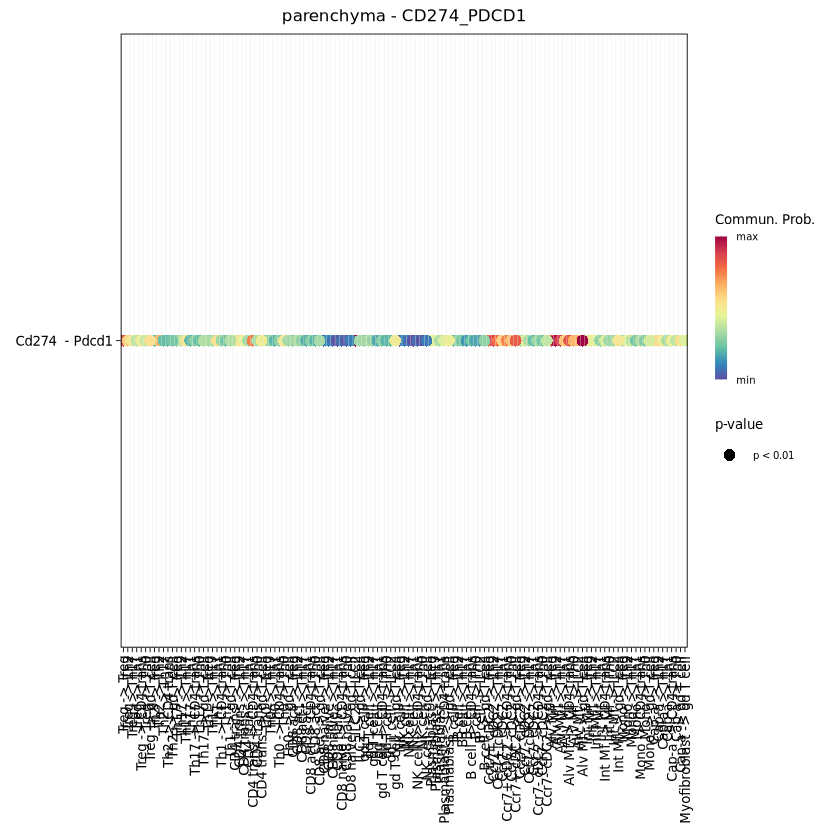

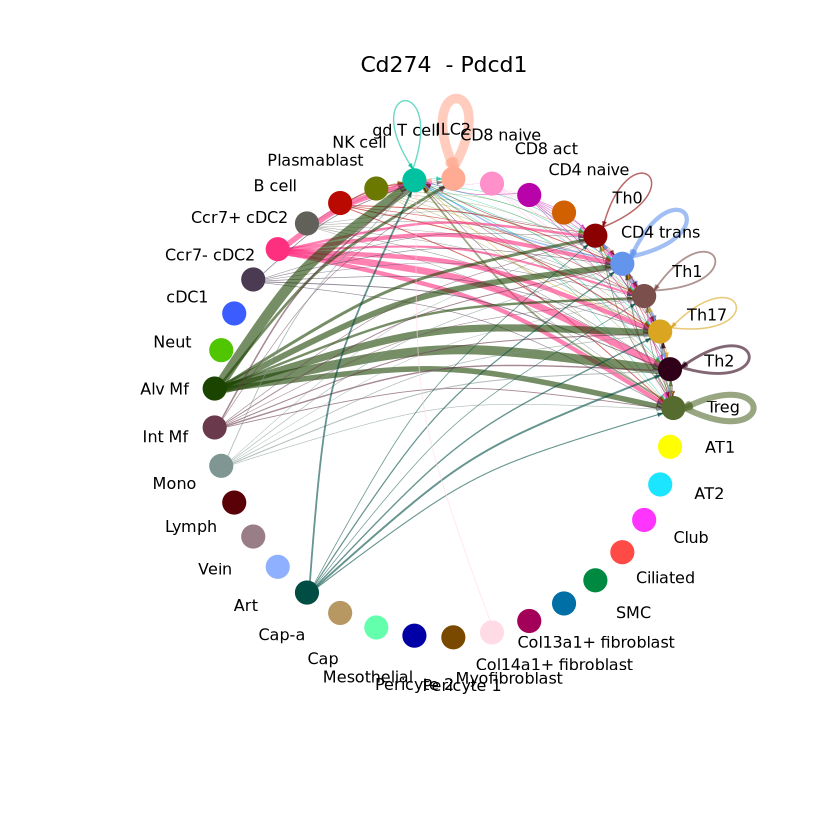

In [26]:
# PDL1
pairLR.use <- extractEnrichedLR(cellchat_tls, signaling = c("PD-L1"))
single_interaction <- pairLR.use[pairLR.use$interaction_name == "CD274_PDCD1", , drop = FALSE]

plot_pathway_results(
    chat_list = chat_list, 
    pathway = 'PD-L1',
    interaction = single_interaction, 
    out_dir = plot_out_dir, 
    palette = celltype_palette_mapped
)

## Plot incoming signal pathways 

In [42]:
while (!is.null(dev.list())) dev.off()

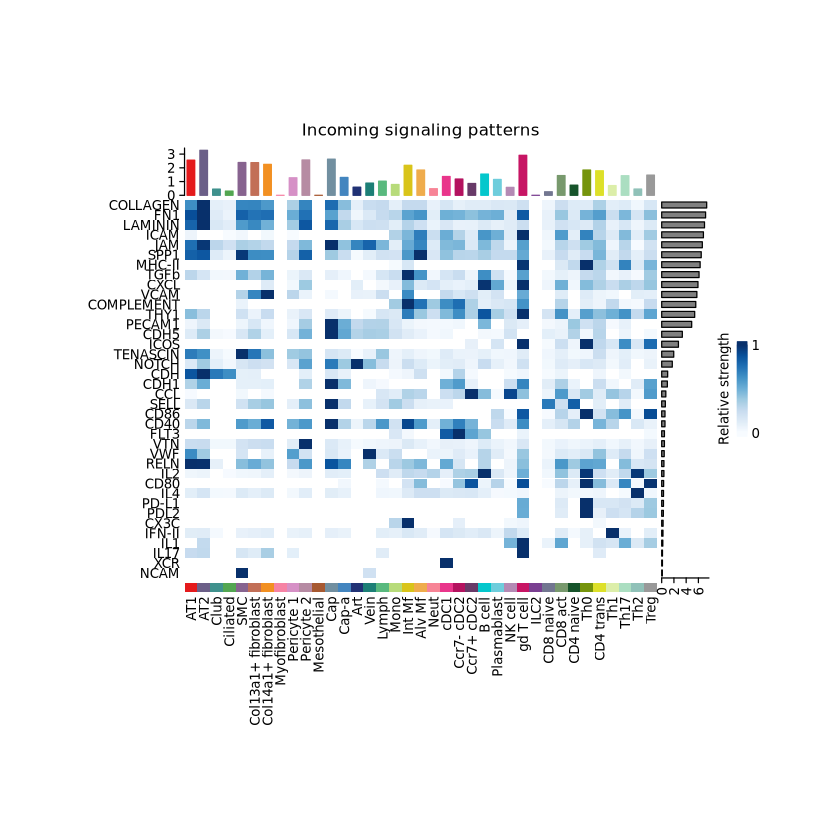

In [46]:
## Incoming signals
print(netAnalysis_signalingRole_heatmap(cellchat_tls, pattern = "incoming", color.heatmap = "Blues"))
# print(netAnalysis_signalingRole_heatmap(cellchat_bronchi, pattern = "incoming", color.heatmap = "Blues"))
# netAnalysis_signalingRole_heatmap(cellchat_vessels, pattern = "incoming", color.heatmap = "Blues")
# netAnalysis_signalingRole_heatmap(cellchat_adv, pattern = "incoming", color.heatmap = "Blues")


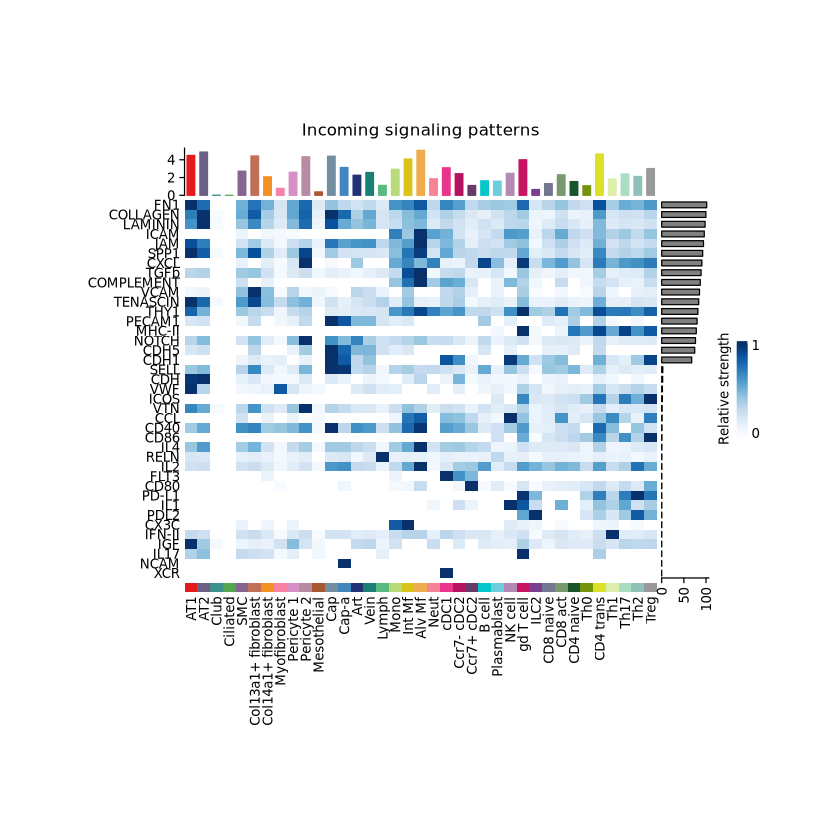

In [47]:
print(netAnalysis_signalingRole_heatmap(cellchat_paren, pattern = "incoming", color.heatmap = "Blues"))

## Plot number of interactions per object

In [28]:
# PD1 setup
pairLR.use <- extractEnrichedLR(cellchat_tls, signaling = c("PD-L1"))
single_interaction <- pairLR.use[pairLR.use$interaction_name == "CD274_PDCD1", , drop = FALSE]


# pairLR.use <- extractEnrichedLR(cellchat_tls, signaling = c("PDL2"))
# single_interaction <- pairLR.use[pairLR.use$interaction_name == "PDCD1LG2_PDCD1", , drop = FALSE]

Skipping bronchi : No significant interactions.



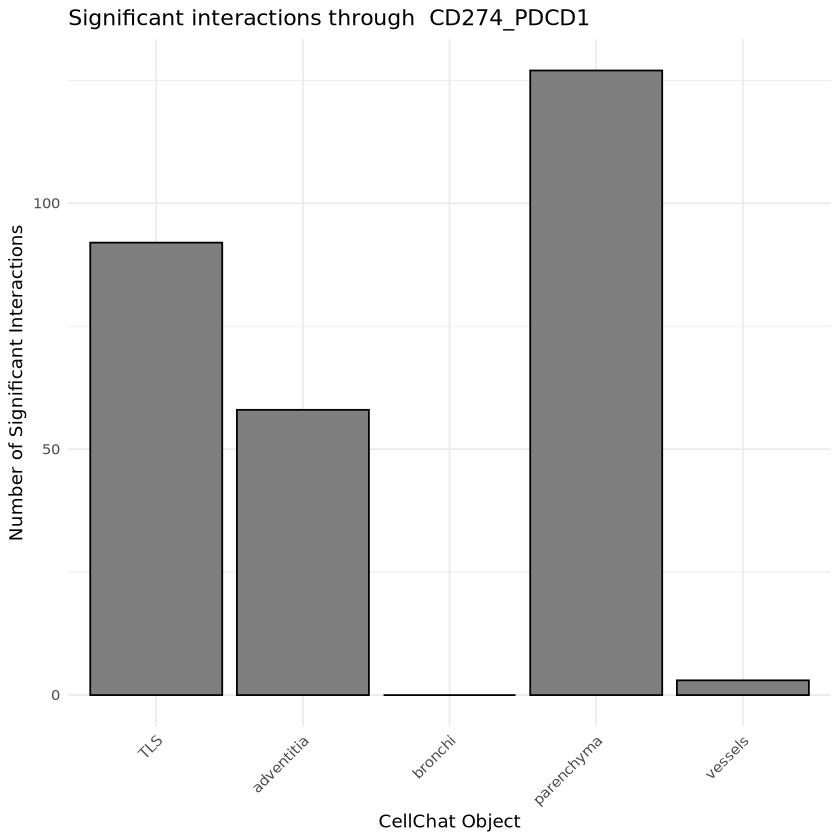

In [29]:
# Initialize a vector to store counts
interaction_counts <- setNames(numeric(length(chat_list)), names(chat_list))

for (obj_name in names(chat_list)) {
    obj <- chat_list[[obj_name]]

    # ... [your label ordering logic here] ...

    # check for sig interactions
    df.net <- NULL
    df.net <- tryCatch({
        subsetCommunication(obj, pairLR.use = single_interaction)
    }, error = function(e) return(NULL))
    
    # Store the count (0 if df.net is NULL, otherwise the number of SR pairs)
    if (is.null(df.net)) {
        interaction_counts[obj_name] <- 0
        message(paste("Skipping", obj_name, ": No significant interactions."))
        next
    } else {
        interaction_counts[obj_name] <- nrow(df.net)
    }
}

# --- NEW: Generate the Bar Plot ---
library(ggplot2)

# Convert results to a data frame for plotting
plot_df <- data.frame(
    Zone = names(interaction_counts),
    Count = as.numeric(interaction_counts)
)

# Create the Bar Plot
p_bar <- ggplot(plot_df, aes(x = Zone, y = Count, fill = Zone)) +
    geom_bar(stat = "identity", color = "black") +
    theme_minimal() +
    labs(
        title = paste("Significant interactions through ", single_interaction$interaction_name),
        x = "CellChat Object",
        y = "Number of Significant Interactions"
    ) +
    scale_fill_manual(values = celltype_palette_mapped) + # Optional: use your existing palette
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Show and save the bar plot
print(p_bar)
ggsave(filename = paste0(plot_out_dir, "/IL21_interaction_summary_barplot.pdf"), plot = p_bar, width = 6, height = 5)

## Cellchat plots

In [15]:
df.net <- subsetCommunication(cellchat_tls)

In [16]:
df.net

,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
,<fct>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>,<chr>
1,Mono,AT1,Tgfb1,TGFbR1_R2,0.0017910196,0.01,TGFB1_TGFBR1_TGFBR2,Tgfb1 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
2,Int Mf,AT1,Tgfb1,TGFbR1_R2,0.0049716619,0.00,TGFB1_TGFBR1_TGFBR2,Tgfb1 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
3,Alv Mf,AT1,Tgfb1,TGFbR1_R2,0.0030894752,0.00,TGFB1_TGFBR1_TGFBR2,Tgfb1 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
4,cDC1,AT1,Tgfb1,TGFbR1_R2,0.0020569006,0.00,TGFB1_TGFBR1_TGFBR2,Tgfb1 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
5,Ccr7- cDC2,AT1,Tgfb1,TGFbR1_R2,0.0031850583,0.00,TGFB1_TGFBR1_TGFBR2,Tgfb1 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
6,B cell,AT1,Tgfb1,TGFbR1_R2,0.0058963251,0.00,TGFB1_TGFBR1_TGFBR2,Tgfb1 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
7,CD4 trans,AT1,Tgfb1,TGFbR1_R2,0.0020005299,0.01,TGFB1_TGFBR1_TGFBR2,Tgfb1 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
8,Alv Mf,AT2,Tgfb1,TGFbR1_R2,0.0038345562,0.00,TGFB1_TGFBR1_TGFBR2,Tgfb1 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
9,Ccr7- cDC2,AT2,Tgfb1,TGFbR1_R2,0.0033947950,0.03,TGFB1_TGFBR1_TGFBR2,Tgfb1 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350


In [32]:
# pdf(file = file.path(plot_out_dir, "tls_incoming_signals_allcells.pdf"))
netAnalysis_signalingRole_heatmap(cellchat_tls, pattern = "incoming", color.heatmap = "Blues")
# dev.off()